# 02e — Retraitement ciblé avec despike (15/05/2026)

Après diagnostic 02d, on rétreait les essais contaminés par des spikes ponctuels
avec la nouvelle étape `despike_mad()` (k=8·MAD, interpolation linéaire).

**Essais ciblés** :
- `008RiMo / silence`
- `011RiJo / beatmove_adaptatif`
- `005DeJe / beatmove_adaptatif` (essai "à surveiller")
- `013WaJe / silence` (essai "à surveiller")

**Exclusion ajoutée dans `participants.py`** :
- `008RiMo / tempo_random` → `excluded=True` (marqueurs Dos cassés)

In [1]:
from resilience import paths, participants, config
from resilience.io import loader, writer
from resilience.processing import preprocess
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
%matplotlib inline

In [2]:
DESPIKE_K = 8.0  # multiplicateur MAD

## Fonction de retraitement + comparaison avant/après

In [3]:
def retreat_and_compare(participant, condition, despike_k=8.0, save_new=True):
    print(f"\n{'═'*70}\n  RETRAITEMENT : {participant} / {condition}\n{'═'*70}")

    # --- Charger ancien .npz (avant despike) ---
    old = writer.load_processed(participant, condition)
    sig_old = old['signal_final']
    t_old   = old['time_final']

    # --- Recharger raw + appliquer crops ---
    raw_path = paths.raw_file(participant, condition)
    data, fmt = loader.load_mat(raw_path)
    trajectories = loader.extract_marker_trajectories(data, fmt)

    trial = participants.get_trial(participant, condition)
    n_before = next(iter(trajectories.values())).shape[0]
    i_start = int(trial.crop_start_s * config.FS_RAW) if trial.crop_start_s else 0
    i_end   = int(trial.crop_end_s * config.FS_RAW) if trial.crop_end_s else n_before
    trajectories = {m: xyz[i_start:i_end] for m, xyz in trajectories.items()}

    # --- Retraiter AVEC despike ---
    out_new = preprocess.run(trajectories, axis='Z',
                              apply_despike=True, despike_k=despike_k,
                              verbose=True)
    sig_new = out_new['signal_final']
    t_new   = out_new['time_final']
    n_spikes = out_new['despike_stats']['n_spikes']

    # --- Métriques avant/après ---
    amp_old = float(np.percentile(sig_old, 95) - np.percentile(sig_old, 5))
    amp_new = float(np.percentile(sig_new, 95) - np.percentile(sig_new, 5))
    f_o, p_o = welch(sig_old, fs=config.FS_CLEAN, nperseg=min(len(sig_old), 4*config.FS_CLEAN))
    f_n, p_n = welch(sig_new, fs=config.FS_CLEAN, nperseg=min(len(sig_new), 4*config.FS_CLEAN))
    mask_o = (f_o >= 0.5) & (f_o <= 2.5)
    mask_n = (f_n >= 0.5) & (f_n <= 2.5)
    f_dom_old = f_o[mask_o][np.argmax(p_o[mask_o])] if mask_o.any() else np.nan
    f_dom_new = f_n[mask_n][np.argmax(p_n[mask_n])] if mask_n.any() else np.nan
    rng_old = (float(sig_old.min()), float(sig_old.max()))
    rng_new = (float(sig_new.min()), float(sig_new.max()))

    print(f"\n  Résultats :")
    print(f"    spikes interpolés      : {n_spikes}")
    print(f"    amplitude p5-p95 (mm)  : {amp_old:.1f}  →  {amp_new:.1f}")
    print(f"    min/max signal (mm)    : ({rng_old[0]:+.0f}, {rng_old[1]:+.0f})  →  ({rng_new[0]:+.0f}, {rng_new[1]:+.0f})")
    print(f"    f_dom (Hz)             : {f_dom_old:.2f}  →  {f_dom_new:.2f}")

    # --- Plot avant/après ---
    fig, axes = plt.subplots(3, 1, figsize=(14, 9))

    axes[0].plot(t_old, sig_old, color='steelblue', linewidth=0.5)
    axes[0].set_title(f'AVANT despike  —  amp={amp_old:.1f}mm, range=({rng_old[0]:+.0f},{rng_old[1]:+.0f})mm',
                       loc='left', fontsize=10)
    axes[0].set_ylabel('Z (mm)')
    axes[0].grid(alpha=0.3)

    axes[1].plot(t_new, sig_new, color='darkorange', linewidth=0.5)
    axes[1].set_title(f'APRÈS despike (k={despike_k}, {n_spikes} spikes)  —  amp={amp_new:.1f}mm, range=({rng_new[0]:+.0f},{rng_new[1]:+.0f})mm',
                       loc='left', fontsize=10)
    axes[1].set_ylabel('Z (mm)')
    axes[1].set_xlabel('Temps (s)')
    axes[1].grid(alpha=0.3)

    # Spectres superposés
    axes[2].semilogy(f_o, p_o, color='steelblue', linewidth=0.8, label='avant')
    axes[2].semilogy(f_n, p_n, color='darkorange', linewidth=0.8, label='après', alpha=0.8)
    axes[2].axvspan(0.5, 2.5, color='green', alpha=0.1, label='Bande marche')
    axes[2].set_xlim(0, 5)
    axes[2].set_xlabel('Fréquence (Hz)')
    axes[2].set_ylabel('PSD')
    axes[2].set_title(f'Spectres comparés  —  f_dom : {f_dom_old:.2f} → {f_dom_new:.2f} Hz',
                       loc='left', fontsize=10)
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.3)

    plt.suptitle(f'Retraitement : {participant} / {condition}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'retreat_{participant}_{condition}.png', dpi=80, bbox_inches='tight')
    plt.show()

    # --- Sauvegarde du nouveau .npz (écrase l'ancien) ---
    if save_new:
        out_path = writer.save_processed(participant, condition, out_new,
                                            trajectories_raw=trajectories)
        print(f"\n  ✅ .npz sauvegardé (overwrite) : {out_path.name}")

    return out_new

## Retraitement essai 1/4 — 008RiMo / silence


══════════════════════════════════════════════════════════════════════
  RETRAITEMENT : 008RiMo / silence
══════════════════════════════════════════════════════════════════════
   → compute_barycenter()
   → despike_mad(k=8.0) : 88 spikes interpolés (0.05% des samples, threshold=±209.8mm)
   → apply_emd_decomposition()
   Fréquences IMFs : IMF0=4.50Hz, IMF1=9.00Hz, IMF2=4.25Hz, IMF3=4.75Hz, IMF4=5.00Hz, IMF5=1.75Hz, IMF6=1.75Hz, IMF7=1.75Hz, IMF8=1.75Hz, IMF9=1.00Hz, IMF10=0.50Hz, IMF11=0.25Hz, IMF12=0.25Hz, IMF13=0.25Hz, IMF14=0.25Hz, IMF15=0.25Hz, IMF16=0.25Hz, IMF17=0.25Hz
   Bande [0.5–2.5 Hz] → IMFs sélectionnées : [5, 6, 7, 8, 9, 10]
   EMD : 18 IMFs extraites, mode='auto', gardées=[5, 6, 7, 8, 9, 10]
   → butterworth_filter(cutoff=5.0 Hz, order=4)
   → downsample_signal(factor=4)  |  400 → 100 Hz

  Résultats :
    spikes interpolés      : 88
    amplitude p5-p95 (mm)  : 39.1  →  38.0
    min/max signal (mm)    : (-149, +207)  →  (-79, +74)
    f_dom (Hz)             : 1.75  → 

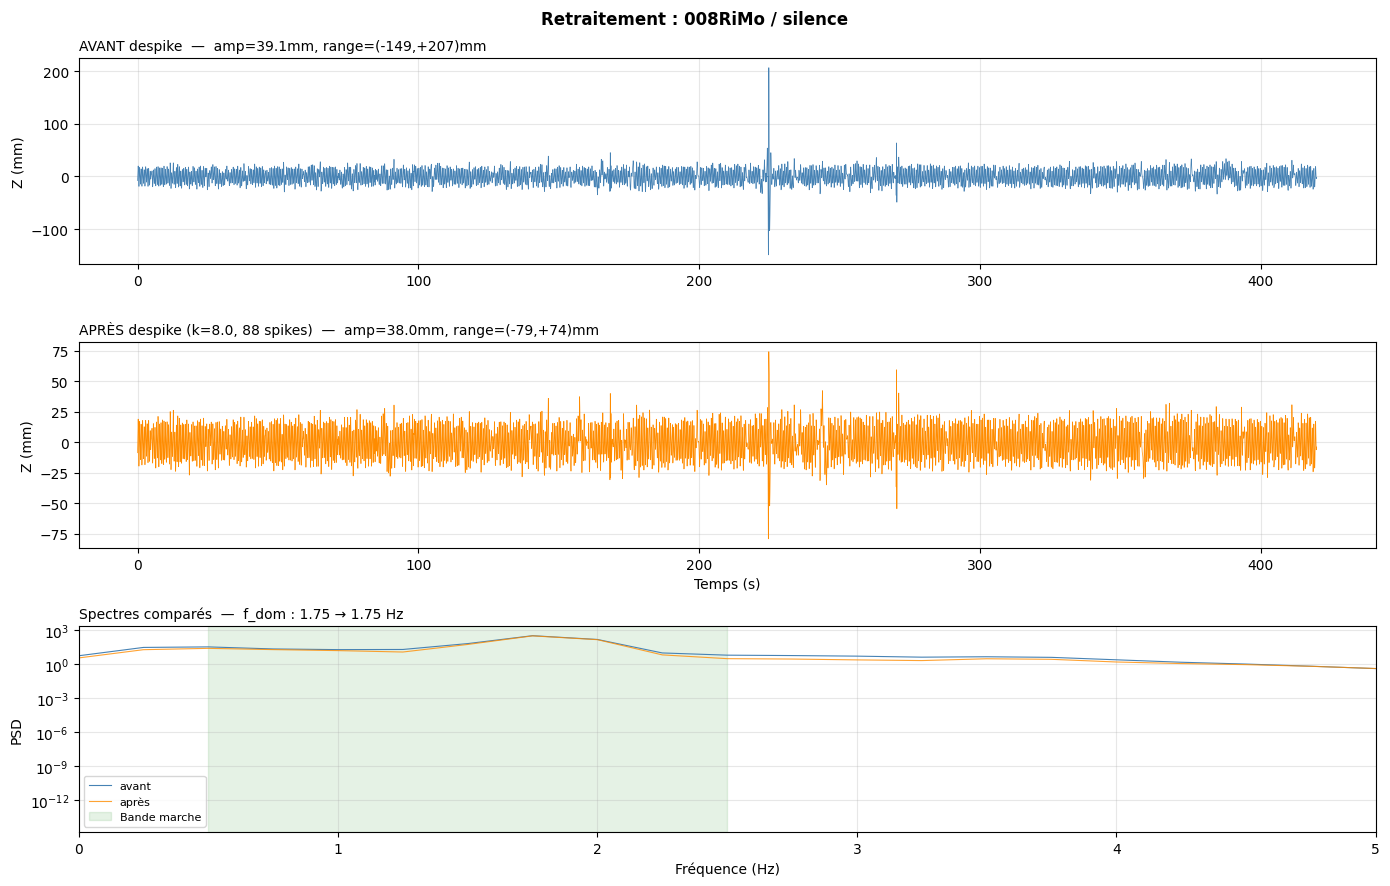


  ✅ .npz sauvegardé (overwrite) : 008RiMo_01_silence.npz


In [4]:
_ = retreat_and_compare('008RiMo', 'silence', despike_k=DESPIKE_K)

## Retraitement essai 2/4 — 011RiJo / beatmove_adaptatif


══════════════════════════════════════════════════════════════════════
  RETRAITEMENT : 011RiJo / beatmove_adaptatif
══════════════════════════════════════════════════════════════════════
   → compute_barycenter()
   → despike_mad(k=8.0) : 20 spikes interpolés (0.01% des samples, threshold=±103.4mm)
   → apply_emd_decomposition()
   Fréquences IMFs : IMF0=8.25Hz, IMF1=24.00Hz, IMF2=58.25Hz, IMF3=38.25Hz, IMF4=24.00Hz, IMF5=1.75Hz, IMF6=1.75Hz, IMF7=1.50Hz, IMF8=1.50Hz, IMF9=1.50Hz, IMF10=0.50Hz, IMF11=0.25Hz, IMF12=0.25Hz, IMF13=0.25Hz, IMF14=0.25Hz, IMF15=0.25Hz, IMF16=0.25Hz, IMF17=0.25Hz, IMF18=0.25Hz
   Bande [0.5–2.5 Hz] → IMFs sélectionnées : [5, 6, 7, 8, 9, 10]
   EMD : 19 IMFs extraites, mode='auto', gardées=[5, 6, 7, 8, 9, 10]
   → butterworth_filter(cutoff=5.0 Hz, order=4)
   → downsample_signal(factor=4)  |  400 → 100 Hz

  Résultats :
    spikes interpolés      : 20
    amplitude p5-p95 (mm)  : 38.2  →  37.6
    min/max signal (mm)    : (-95, +91)  →  (-44, +36)
    f_dom 

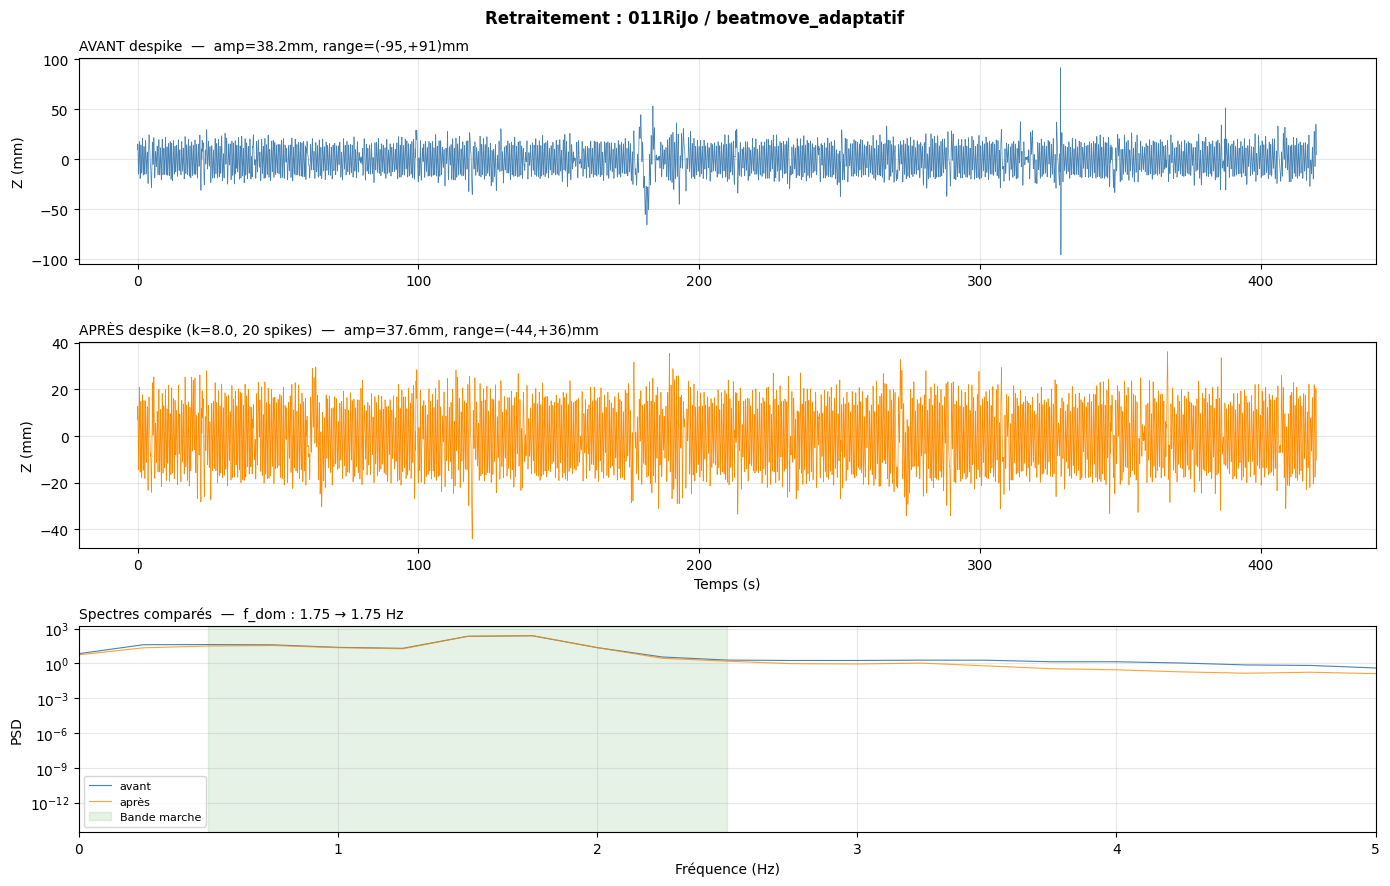


  ✅ .npz sauvegardé (overwrite) : 011RiJo_03_beatmove_adaptatif.npz


In [5]:
_ = retreat_and_compare('011RiJo', 'beatmove_adaptatif', despike_k=DESPIKE_K)

## Retraitement essai 3/4 — 005DeJe / beatmove_adaptatif


══════════════════════════════════════════════════════════════════════
  RETRAITEMENT : 005DeJe / beatmove_adaptatif
══════════════════════════════════════════════════════════════════════
   → compute_barycenter()
   → despike_mad(k=8.0) : 13 spikes interpolés (0.01% des samples, threshold=±164.4mm)
   → apply_emd_decomposition()
   Fréquences IMFs : IMF0=27.00Hz, IMF1=85.25Hz, IMF2=35.00Hz, IMF3=30.75Hz, IMF4=22.25Hz, IMF5=1.75Hz, IMF6=1.75Hz, IMF7=1.75Hz, IMF8=1.75Hz, IMF9=0.50Hz, IMF10=0.25Hz, IMF11=0.25Hz, IMF12=0.25Hz, IMF13=0.25Hz, IMF14=0.25Hz, IMF15=0.25Hz, IMF16=0.25Hz
   Bande [0.5–2.5 Hz] → IMFs sélectionnées : [5, 6, 7, 8, 9]
   EMD : 17 IMFs extraites, mode='auto', gardées=[5, 6, 7, 8, 9]
   → butterworth_filter(cutoff=5.0 Hz, order=4)
   → downsample_signal(factor=4)  |  400 → 100 Hz

  Résultats :
    spikes interpolés      : 13
    amplitude p5-p95 (mm)  : 68.6  →  66.5
    min/max signal (mm)    : (-60, +70)  →  (-57, +54)
    f_dom (Hz)             : 1.75  →  1.75


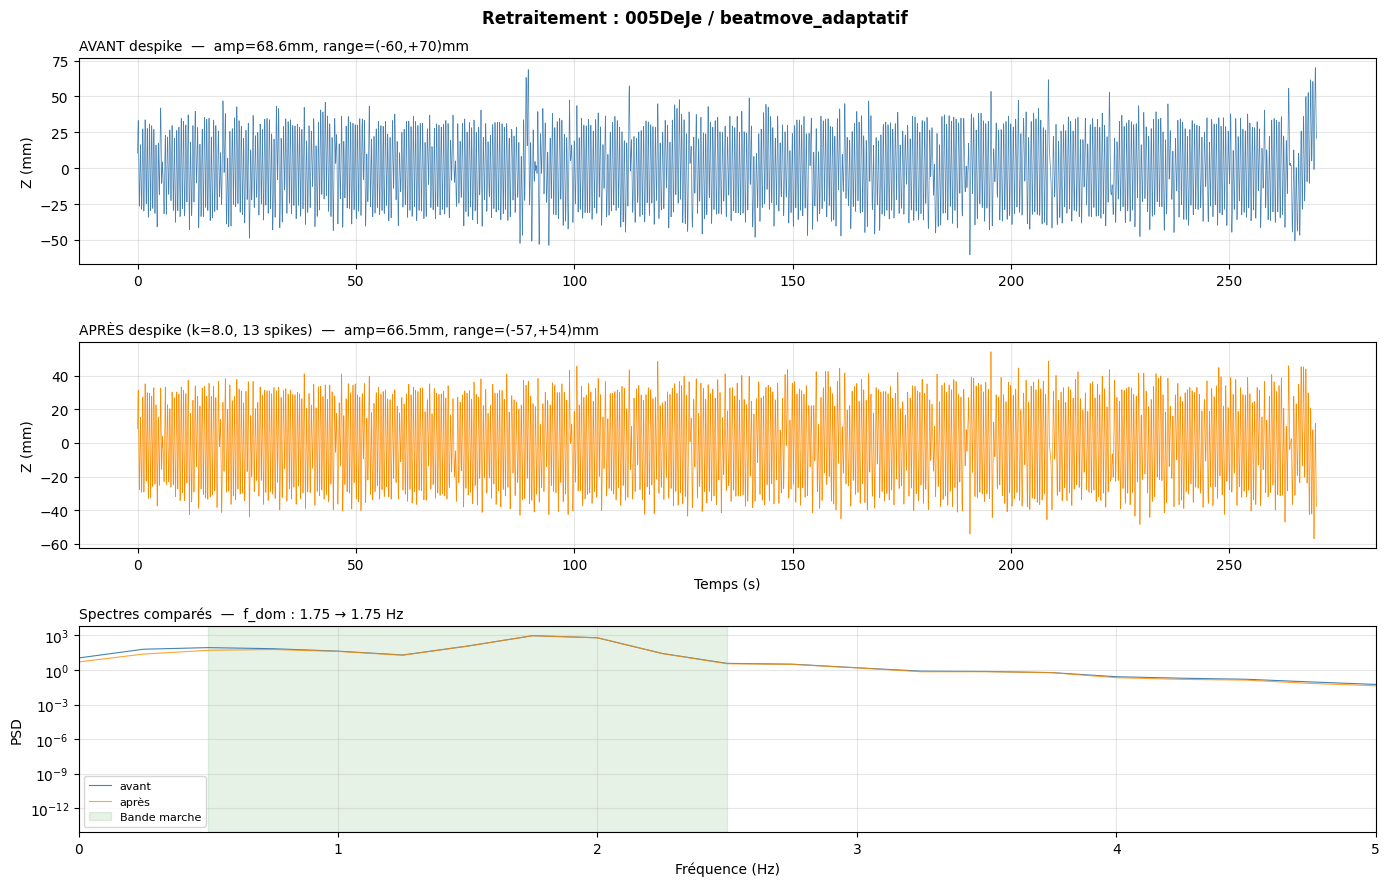


  ✅ .npz sauvegardé (overwrite) : 005DeJe_03_beatmove_adaptatif.npz


In [6]:
_ = retreat_and_compare('005DeJe', 'beatmove_adaptatif', despike_k=DESPIKE_K)

## Retraitement essai 4/4 — 013WaJe / silence


══════════════════════════════════════════════════════════════════════
  RETRAITEMENT : 013WaJe / silence
══════════════════════════════════════════════════════════════════════
   → compute_barycenter()
   → despike_mad(k=8.0) : 9 spikes interpolés (0.01% des samples, threshold=±81.7mm)
   → apply_emd_decomposition()
   Fréquences IMFs : IMF0=191.75Hz, IMF1=89.25Hz, IMF2=61.00Hz, IMF3=38.25Hz, IMF4=22.25Hz, IMF5=5.25Hz, IMF6=1.75Hz, IMF7=1.75Hz, IMF8=0.75Hz, IMF9=0.25Hz, IMF10=0.25Hz, IMF11=0.25Hz, IMF12=0.25Hz, IMF13=0.25Hz, IMF14=0.25Hz, IMF15=0.25Hz
   Bande [0.5–2.5 Hz] → IMFs sélectionnées : [6, 7, 8]
   EMD : 16 IMFs extraites, mode='auto', gardées=[6, 7, 8]
   → butterworth_filter(cutoff=5.0 Hz, order=4)
   → downsample_signal(factor=4)  |  400 → 100 Hz

  Résultats :
    spikes interpolés      : 9
    amplitude p5-p95 (mm)  : 34.7  →  33.7
    min/max signal (mm)    : (-31, +34)  →  (-39, +41)
    f_dom (Hz)             : 1.75  →  1.75


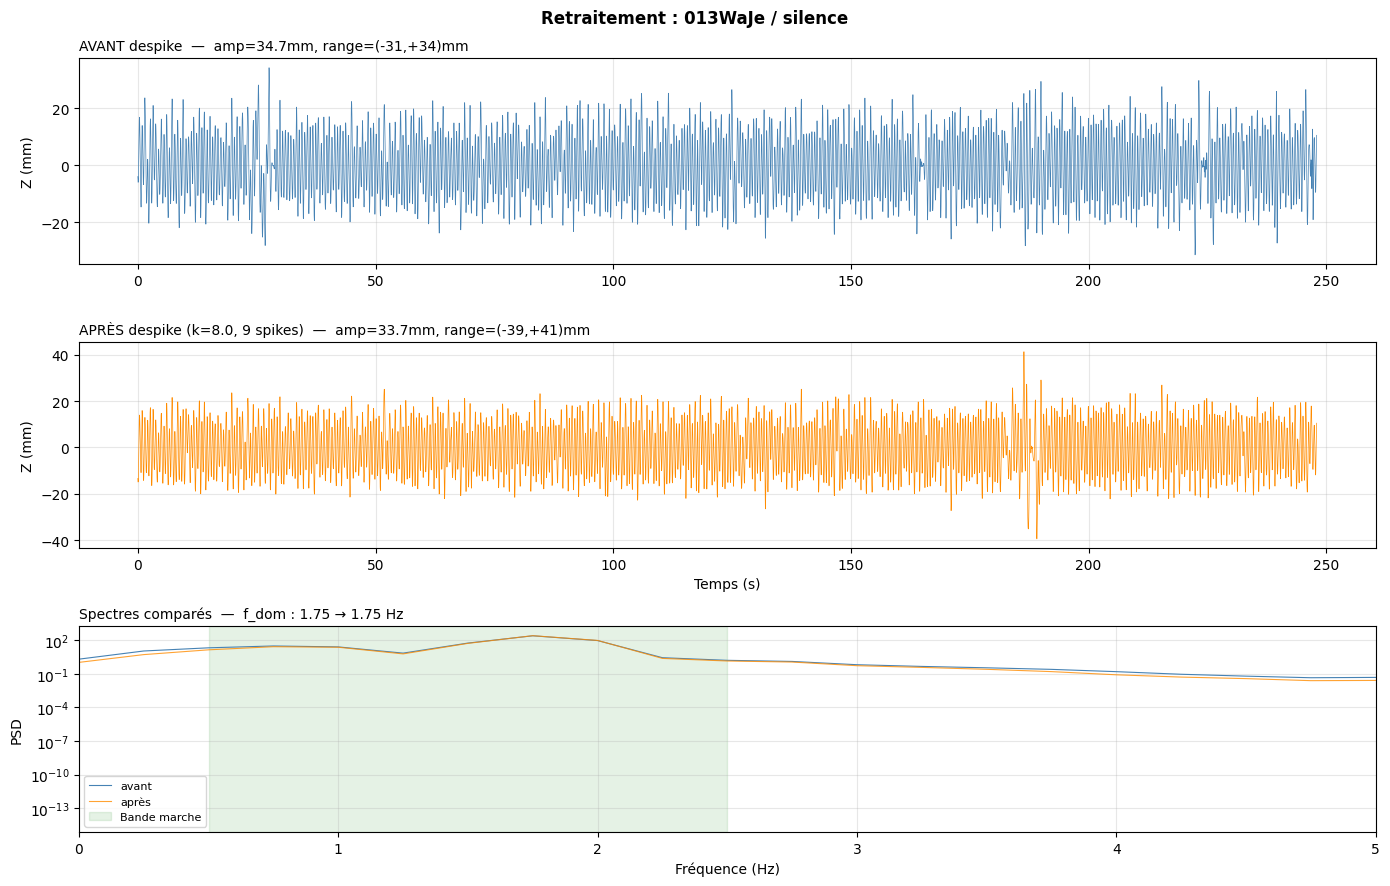


  ✅ .npz sauvegardé (overwrite) : 013WaJe_01_silence.npz


In [7]:
_ = retreat_and_compare('013WaJe', 'silence', despike_k=DESPIKE_K)

## ✅ Bilan

- 42 essais théoriques
- −4 EXCLUDED (P005/sil, P007/sil, P007/bm, P008/tr) → **38 essais exploitables**
- 4 essais retraités avec despike (.npz écrasés)

Prochaine étape → **Notebook 03 : detection sable** (PCA + bbox absolue).